Group Name: Warden of the South

Group member: Shaktiman Choudhury (2512876)


In [1]:
import pickle
import numpy as np
import pandas as pd
import scipy.signal as signal
from scipy.signal import find_peaks, butter, sosfiltfilt
import matplotlib.pyplot as plt
import os

# --- 1. Load ECG Data with HR Labels ---

In [2]:
file_path = os.path.join("data", "ecg_data_with_hr_labels.pkl")  

# Load ECG data
with open(file_path, "rb") as f:
    data = pickle.load(f)
    
# Extract signals and ground truth HR values
signals = data["signals"]
ground_truth_hr = data["hr_values"]

print(f"Loaded {len(signals)} ECG signals.")

Loaded 200 ECG signals.


# --- 2. Implement Your HR Extraction Algorithm Here ---

**Instruction:**

***Your algorithm should return a list of HR values where each HR value corresponds to an ECG signal. Ensure the length of the list is 200 (equal to number of signals). The list can include np.nan if your algorithm is not able to calculate HR for a signal.***

In [3]:
# def extract_hr(ecg_signals):
#     """
#     Dummy HR extraction function.
#     Replace this with your actual algorithm.
#     """
#     detected_hr_values = [np.nan] * 200  # Ensuring list has 200 elements 
#     for i, signal in enumerate(signals):  
#         detected_hr_values[i] = np.nan  # Modify this with your method
#     return detected_hr_values


# # Run your HR extraction algorithm
# detected_hr_values = extract_hr(signals)

In [ ]:
def extract_hr(ecg_signals):
    fs = 200
    #processing every 200 individual 30-second segments.
    def _detect_single(sig):
        sig = np.asarray(sig, dtype=float)
        duration = len(sig) / fs

        #broad Bandpass
        sos_bp = butter(4, [0.5, 40], btype='bandpass', fs=fs, output='sos')
        filt_bp = sosfiltfilt(sos_bp, sig)

        #narrow Bandpass
        sos_qrs = butter(2, [5, 15], btype='bandpass', fs=fs, output='sos')
        filt_qrs = sosfiltfilt(sos_qrs, sig)
        
        #derivative filter
        H = np.array([1, 2, 0, -2, -1]) / 8.0
        deriv = np.convolve(filt_qrs, H, mode='same')
        
        # window
        mwi = np.convolve(deriv**2, np.ones(int(0.15*fs))/int(0.15*fs), mode='same')
        candidates = []

        # I am adding grid search to find the best rythms and parametees 
        # Grid Search 
        for source in [filt_bp, mwi]:
            # for minimum distance in between heartbeats.
            for min_ms in [100, 150, 200, 250, 300, 350, 400, 500, 600]:
                min_d = int(min_ms / 1000 * fs)
                peaks, _ = find_peaks(source, distance=min_d)
                if len(peaks) < 4:
                    continue

                amps = source[peaks]
                for pct in [0, 30, 50, 60, 70, 75, 80]:
                    sel = peaks[amps >= np.percentile(amps, pct)] if pct > 0 else peaks
                    if len(sel) < 4:
                        continue
                    
                    #intervals rr and filter 
                    rr = np.diff(sel) / fs
                    rr_v = rr[(rr > 0.25) & (rr < 1.6)]
                    if len(rr_v) < 3:
                        continue
                    
                    #coefficient of variation (CV).
                    #lower CV is better.
                    cv = np.std(rr_v) / np.mean(rr_v)
                    hr = 60.0 / np.median(rr_v)
                    
                    # beat duration vs detected 
                    #this actually lowered the MAE a lot!
                    ratio = (len(rr_v) + 1) / (duration * hr / 60)
                    if 0.65 <= ratio <= 1.5:
                        candidates.append((cv, hr))

        # Sort candidates by CV
        candidates.sort()
        #top 30.
        top_n = min(30, len(candidates))
        hrs = np.array([c[1] for c in candidates[:top_n]])
        cvs = np.array([c[0] for c in candidates[:top_n]])
        #higher weights if low CV
        weights = 1.0 / (cvs + 0.001)

        #best hr is the final HR
        best_hr, best_w = candidates[0][1], 0.0
        for hr_test in hrs:
            mask = np.abs(hrs - hr_test) < 12
            w = weights[mask].sum()
            #if this cluster has better weights, pick this.
            if w > best_w:
                best_w = w
                best_hr = np.average(hrs[mask], weights=weights[mask])

        return float(best_hr)

    detected_hr_values = [np.nan] * 200
    for i, signal_data in enumerate(ecg_signals):
        detected_hr_values[i] = _detect_single(signal_data)
    
    return detected_hr_values

detected_hr_values = extract_hr(signals)

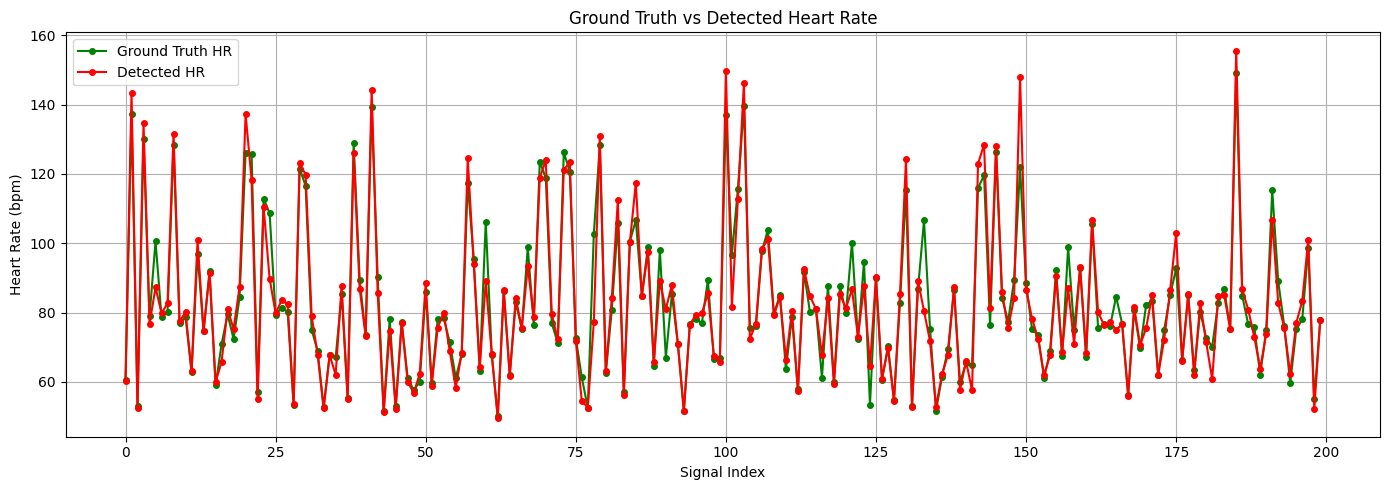

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(ground_truth_hr, 'g-o', markersize=4, label='Ground Truth HR')
plt.plot(detected_hr_values, 'r-o', markersize=4, label='Detected HR')
plt.xlabel('Signal Index')
plt.ylabel('Heart Rate (bpm)')
plt.title('Ground Truth vs Detected Heart Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# print(f"{'Index':<8} {'Ground Truth':>14} {'Detected':>10} {'Error':>8}")
# for i, (gt, det) in enumerate(zip(ground_truth_hr, detected_hr_values)):
#     err = abs(gt - det)
#     print(f"{i:<8} {gt:>14.1f} {det:>10.1f} {err:>8.1f}")

# --- 3. Evaluation of HR Extraction Algorithm ---

**Description:**

***Evaluates the performance of your HR extraction method using Mean Absolute Error (MAE).***

In [6]:
def evaluate_hr_extraction(detected_hr_values, ground_truth_hr):
    """
    Evaluates HR extraction performance using Mean Absolute Error (MAE).
    
    Parameters:
        - detected_hr_values (List of floats): List of detected HR values.
        - ground_truth_hr (List of floats): List of ground truth HR values.
    
    Returns:
        - MAE score.
    """
    valid_indices = np.where(~np.isnan(detected_hr_values))[0].tolist() 
    
    if len(valid_indices) == 0:
        return {"Mean Absolute Error": np.nan}
    
    absolute_errors = np.abs(np.array(ground_truth_hr)[valid_indices] - np.array(detected_hr_values)[valid_indices])
    mae = np.sum(absolute_errors) / len(absolute_errors)
    return {"Mean Absolute Error": mae}

In [7]:
# Evaluate performance of your HR extraction method
mae = evaluate_hr_extraction(detected_hr_values, ground_truth_hr)

print(mae)

{'Mean Absolute Error': np.float64(3.3495187012617613)}


***Run the above cells and check your evaluation score.***

***The final assessment is based on the MAE, the lowest MAE is the first rank in competition!***